In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Conv1D, MaxPooling1D, Dense, Dropout, Flatten, Concatenate, LSTM, BatchNormalization, SpatialDropout1D, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.losses import Huber
import os
import random
from scipy import stats
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt 
import xgboost as xgb
from scipy import stats
import shap
from Common_Functions import set_global_determinism, evaluate, \
                                ROC_AUC, CNN_LSTM_Explain, feature_importance, \
                                analyse_profit, analyse_profit, \
                                Prepare_Data, Prepare_Data_XGBoost, \
                                best_threshold,CNN_LSTM_Model, CNN_LSTM_Results, \
                                XGBoost_Results, Meta_Model, feature_importance_table

folder = "exported_csvs"

data = {
    os.path.splitext(f)[0]: pd.read_csv(os.path.join(folder, f))
    for f in os.listdir(folder) if f.endswith(".csv")
}

train_idx, val_idx, test_idx = np.array(data['train_indices']).ravel(), np.array(data['val_indices']).ravel() ,np.array(data['test_indices']).ravel()

win_features = [
    #'back_prices_0_scaled_seq', 
    #'back_volumes_0_scaled_seq', 
    #'back_prices_1_scaled_seq', 
    #'back_volumes_1_scaled_seq',
    #'lay_prices_0_scaled_seq', 
    #'lay_volumes_0_scaled_seq', 
    #'lay_prices_1_scaled_seq', 
    #'lay_volumes_1_scaled_seq',
    'back_VWAP_scaled_seq',
    'lay_VWAP_scaled_seq',
    'others_back_PVT_seq', 
    #'others_lay_PVT_seq',
    'back_PVT_seq',
    'lay_PVT_seq',
    'WOM_seq',
    'back_VWAP_log_return_seq',
    'lay_VWAP_log_return_seq',
    'implied_win_prob',
    'implied_lose_prob'
]

lose_features = [
    #'back_prices_0_scaled_seq', 
    #'back_volumes_0_scaled_seq', 
    #'back_prices_1_scaled_seq', 
    #'back_volumes_1_scaled_seq',
    #'lay_prices_0_scaled_seq', 
    #'lay_volumes_0_scaled_seq', 
    #'lay_prices_1_scaled_seq', 
    'lay_volumes_1_scaled_seq',
    #'back_VWAP_scaled_seq',
    'lay_VWAP_scaled_seq',
    #'others_back_PVT_seq', 
    #'others_lay_PVT_seq',
    #'back_PVT_seq',
    #'lay_PVT_seq',
    'WOM_seq',
    #'back_VWAP_log_return_seq',
    'lay_VWAP_log_return_seq',
    #'implied_win_prob',
    'implied_lose_prob'
]

win_target_feature = 'win'
lose_target_feature = 'lose'

back_profit_seq = np.array(data['back_profit'])[test_idx].ravel()
lay_profit_seq = np.array(data['lay_profit'])[test_idx].ravel()

/opt/anaconda3/envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
win_results = CNN_LSTM_Results(win_features, win_target_feature)
lose_results = CNN_LSTM_Results(lose_features, lose_target_feature)
win_XGBoost_results = XGBoost_Results(win_features, win_target_feature)
lose_XGBoost_results = XGBoost_Results(lose_features, lose_target_feature)
baseline_win_XGBoost_results = XGBoost_Results(['implied_win_prob'], win_target_feature,1)
baseline_lose_XGBoost_results = XGBoost_Results(['implied_lose_prob'], lose_target_feature,1)

869/869 ━━━━━━━━━━━━━━━━━━━━ 1s 625us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 1s 535us/step
val_set best precision: 0.6415094339622641
869/869 ━━━━━━━━━━━━━━━━━━━━ 1s 569us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 1s 448us/step
val_set best precision: 0.9946236559139785
Best params: {'max_depth': 3, 'learning_rate': 0.05}, Best PR-AUC: 0.4049
val_set best precision: 1.0
Best params: {'max_depth': 3, 'learning_rate': 0.01}, Best PR-AUC: 0.9611
val_set best precision: 0.9915540540540541
Best params: {'max_depth': 3, 'learning_rate': 0.05}, Best PR-AUC: 0.3933
val_set best precision: 0.7857142857142857
Best params: {'max_depth': 3, 'learning_rate': 0.05}, Best PR-AUC: 0.9627
val_set best precision: 1.0


In [3]:
print( win_results['metrics'], '\n', lose_results['metrics'] )

{'f1_score': 0.1329369292843491, 'precision_score': 0.5452961672473867, 'recall_score': 0.07569528415961306, 'accuracy_score': 0.887225521336832, 'log_loss': 0.5456860373689139, 'log_loss_ci': (0.5411392875069049, 0.5503256285932437)} 
 {'f1_score': 0.05350480754648306, 'precision_score': 0.9810901001112347, 'recall_score': 0.027502338634237605, 'accuracy_score': 0.1381024720342494, 'log_loss': 0.5379237311399072, 'log_loss_ci': (0.5330777609238402, 0.5428581389600444)}


In [4]:
print( win_XGBoost_results['metrics'], '\n', lose_XGBoost_results['metrics'] )

{'f1_score': 0.01811248808388942, 'precision_score': 0.6229508196721312, 'recall_score': 0.009189842805320435, 'accuracy_score': 0.8862035630437785, 'log_loss': 0.5199918329352388, 'log_loss_ci': (0.5164630128604969, 0.5236222379521145)} 
 {'f1_score': 0.14583995148294684, 'precision_score': 0.9874853343762221, 'recall_score': 0.0787340193327097, 'accuracy_score': 0.183068636928601, 'log_loss': 0.5141226870203993, 'log_loss_ci': (0.5101407957768331, 0.5181684228454992)}


In [5]:
print( baseline_win_XGBoost_results['metrics'], '\n', baseline_lose_XGBoost_results['metrics'] )

{'f1_score': 0.016706443914081145, 'precision_score': 0.6363636363636364, 'recall_score': 0.008464328899637243, 'accuracy_score': 0.8862035630437785, 'log_loss': 0.5371037030917483, 'log_loss_ci': (0.533029062827651, 0.5414548657214068)} 
 {'f1_score': 0.07601163871974083, 'precision_score': 1.0, 'recall_score': 0.03950732772061116, 'accuracy_score': 0.14920591078580306, 'log_loss': 0.5467475376322636, 'log_loss_ci': (0.5428863552849222, 0.5508506161880754)}


In [6]:
win_meta_results = Meta_Model(win_results, win_XGBoost_results, max_depth=3)
lose_meta_results = Meta_Model(lose_results, lose_XGBoost_results, max_depth=3)

val_set best precision: 0.7209302325581395
val_set best precision: 0.9781746031746031


In [7]:
print( win_meta_results['metrics'], '\n', lose_meta_results['metrics'] )

{'f1_score': 0.06011932078935291, 'precision_score': 0.5874439461883408, 'recall_score': 0.0316807738814994, 'accuracy_score': 0.8868664549095429, 'log_loss': 0.3083508024386706, 'log_loss_ci': (0.30199180676235937, 0.3150157413254776)} 
 {'f1_score': 0.38618893813064925, 'precision_score': 0.9800482907612149, 'recall_score': 0.240473963205488, 'accuracy_score': 0.3228835796160751, 'log_loss': 0.308114996764553, 'log_loss_ci': (0.30187495437227585, 0.31450695937036294)}


In [8]:
print( sum(win_results['forecast']*back_profit_seq>0),
       sum(win_results['forecast']*back_profit_seq<0),
       sum(win_results['forecast']*back_profit_seq),
       sum(lose_results['forecast']*lay_profit_seq>0),
       sum(lose_results['forecast']*lay_profit_seq<0),
       sum(lose_results['forecast']*lay_profit_seq) )

313 261 16.28600000000001 882 17 -1193.0999999999906


In [9]:
print( sum(win_XGBoost_results['forecast']*back_profit_seq>0),
       sum(win_XGBoost_results['forecast']*back_profit_seq<0),
       sum(win_XGBoost_results['forecast']*back_profit_seq),
       sum(lose_XGBoost_results['forecast']*lay_profit_seq>0),
       sum(lose_XGBoost_results['forecast']*lay_profit_seq<0),
       sum(lose_XGBoost_results['forecast']*lay_profit_seq) )

38 23 -14.564000000000004 2525 32 -1970.2499999999316


In [10]:
print( sum(baseline_win_XGBoost_results['forecast']*back_profit_seq>0),
       sum(baseline_win_XGBoost_results['forecast']*back_profit_seq<0),
       sum(baseline_win_XGBoost_results['forecast']*back_profit_seq),
       sum(baseline_lose_XGBoost_results['forecast']*lay_profit_seq>0),
       sum(baseline_lose_XGBoost_results['forecast']*lay_profit_seq<0),
       sum(baseline_lose_XGBoost_results['forecast']*lay_profit_seq) )

35 20 -12.285999999999998 1267 0 1203.6500000000287


In [11]:
print( sum(win_meta_results['forecast']*back_profit_seq>0),
       sum(win_meta_results['forecast']*back_profit_seq<0),
       sum(win_meta_results['forecast']*back_profit_seq),
       sum(lose_meta_results['forecast']*lay_profit_seq>0),
       sum(lose_meta_results['forecast']*lay_profit_seq<0),
       sum(lose_meta_results['forecast']*lay_profit_seq) )

131 92 -34.012 7712 157 -2104.0999999999713


In [12]:
print( analyse_profit(win_results['forecast']*back_profit_seq),
       analyse_profit(lose_results['forecast']*lay_profit_seq),
       analyse_profit(win_XGBoost_results['forecast']*back_profit_seq),
       analyse_profit(lose_XGBoost_results['forecast']*lay_profit_seq),
       analyse_profit(baseline_win_XGBoost_results['forecast']*back_profit_seq),
       analyse_profit(baseline_lose_XGBoost_results['forecast']*lay_profit_seq),
       analyse_profit(win_meta_results['forecast']*back_profit_seq),
       analyse_profit(lose_meta_results['forecast']*lay_profit_seq))

{'total_return': 16.285999999999994, 'average_return_per_bet': 0.02837282229965156, 'positive_rate': 0.5452961672473867, 'confidence_interval_95': (-0.14894613018340008, 0.20569177478270323), 'number_of_bets': 574, 'total_observations': 36205, 'bets_ratio': 0.015854163789531833} {'total_return': -1193.1000000000006, 'average_return_per_bet': -1.3271412680756403, 'positive_rate': 0.9810901001112347, 'confidence_interval_95': (-2.654828463091091, 0.0005459269398107036), 'number_of_bets': 899, 'total_observations': 36205, 'bets_ratio': 0.024830824471758044} {'total_return': -14.564, 'average_return_per_bet': -0.23875409836065573, 'positive_rate': 0.6229508196721312, 'confidence_interval_95': (-0.392290124187998, -0.08521807253331345), 'number_of_bets': 61, 'total_observations': 36205, 'bets_ratio': 0.0016848501588178429} {'total_return': -1970.25, 'average_return_per_bet': -0.7705318732890105, 'positive_rate': 0.9874853343762221, 'confidence_interval_95': (-1.4366074849979316, -0.10445626

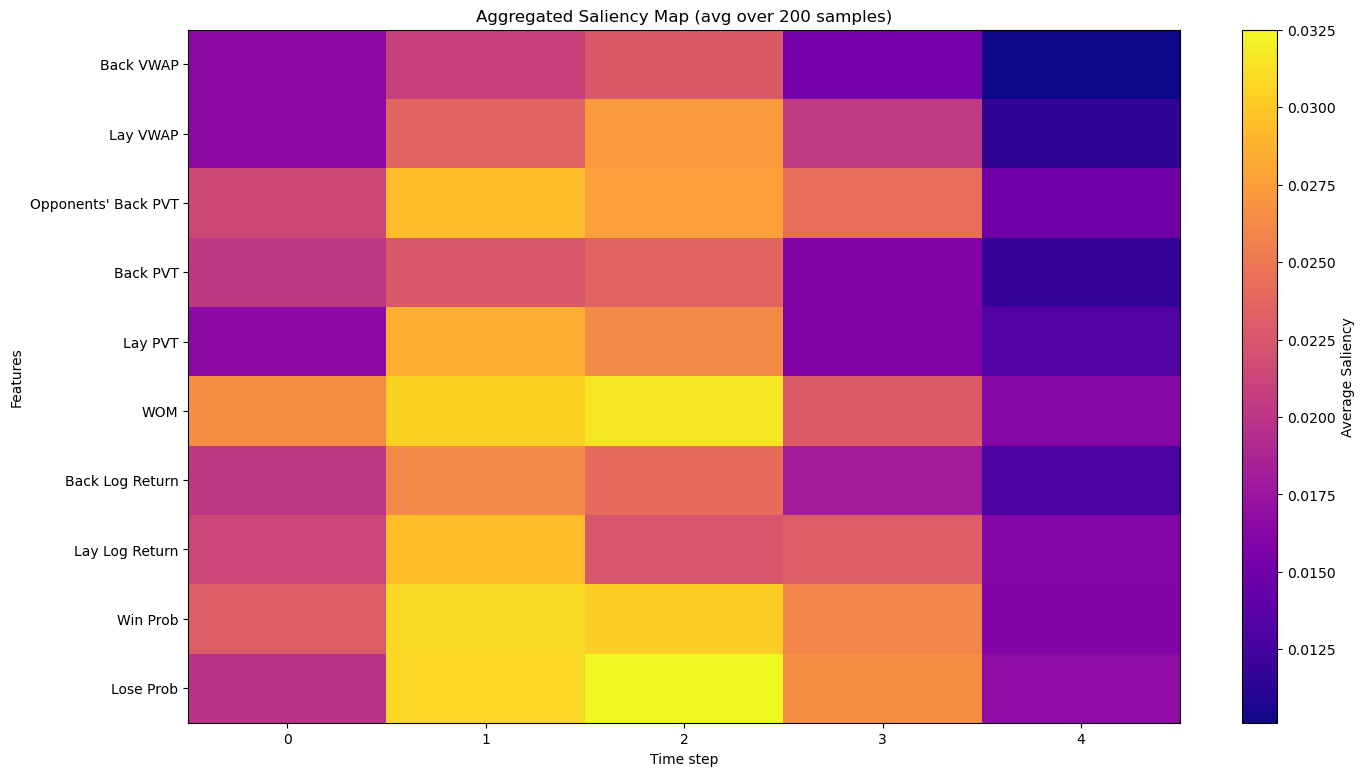

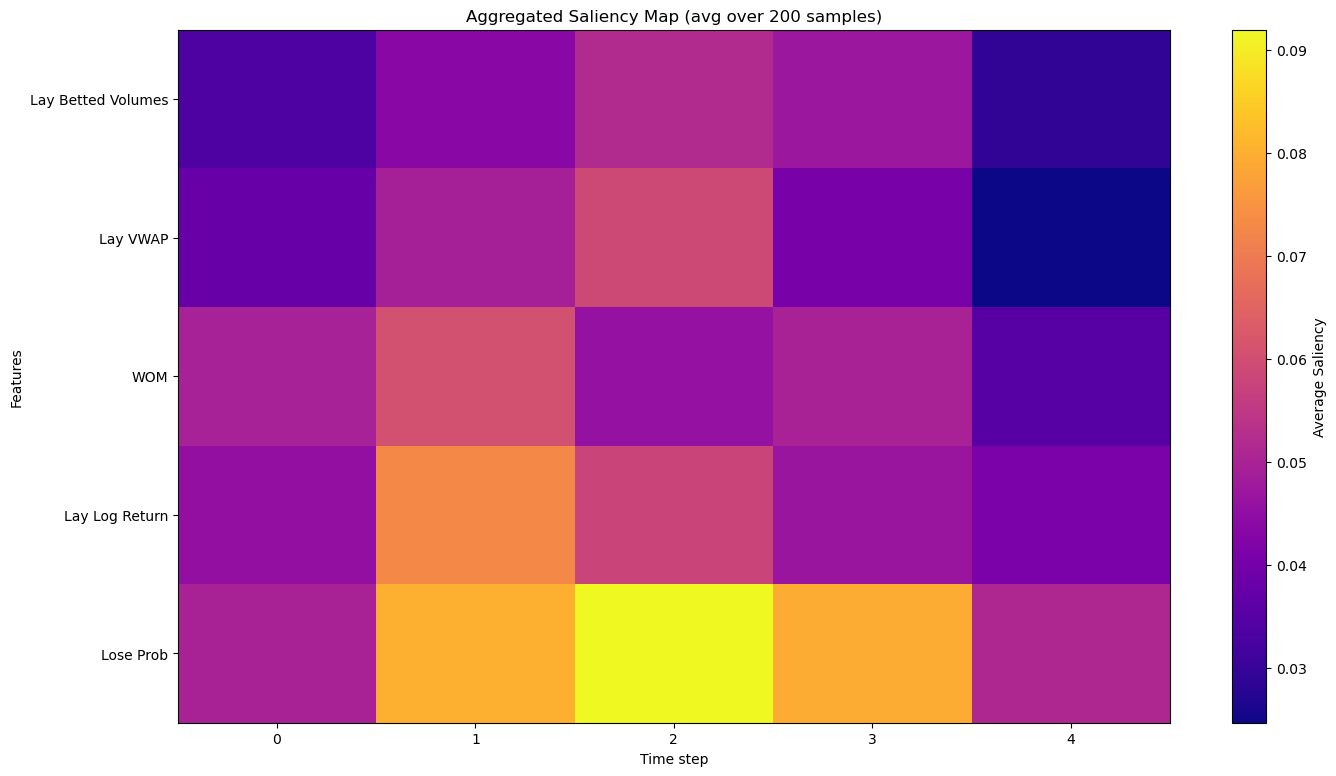

In [13]:
CNN_LSTM_Explain(win_results['model'], win_results['X_test'],  'task3_win',['Back VWAP',
                                                                                        'Lay VWAP', 
                                                                                        'Opponents\' Back PVT',
                                                                                        'Back PVT',
                                                                                        'Lay PVT',
                                                                                        'WOM',
                                                                                        'Back Log Return',
                                                                                        'Lay Log Return',
                                                                                        'Win Prob',
                                                                                        'Lose Prob'])
CNN_LSTM_Explain(lose_results['model'], lose_results['X_test'], 'task_lose',['Lay Betted Volumes',
                                                                                            'Lay VWAP',
                                                                                            'WOM',
                                                                                            'Lay Log Return',
                                                                                            'Lose Prob'])

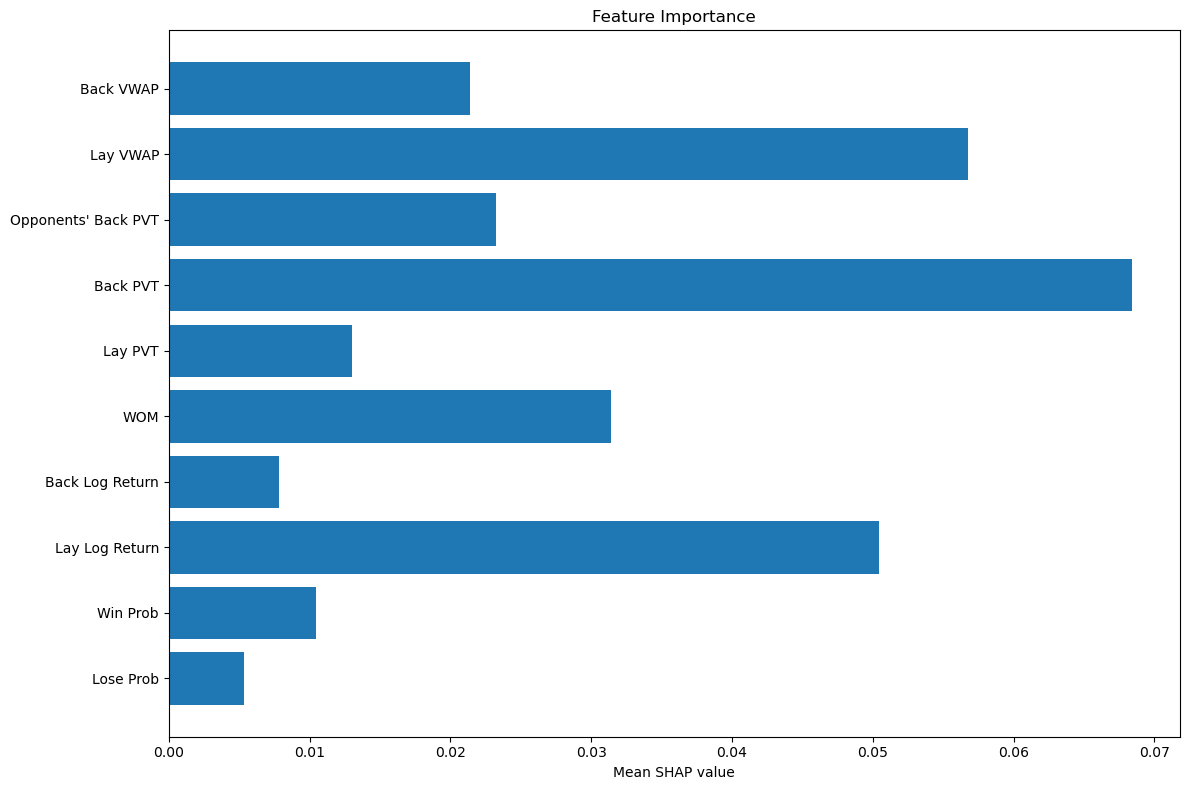

"\\begin{table}[h!]\n\\begin{tabular}{lr}\n\\toprule\nfeature_names & feature_importance (%) \\\\\n\\midrule\nBack VWAP & 7.4 \\\\\nLay VWAP & 19.7 \\\\\nOpponents' Back PVT & 8.1 \\\\\nBack PVT & 23.7 \\\\\nLay PVT & 4.5 \\\\\nWOM & 10.9 \\\\\nBack Log Return & 2.7 \\\\\nLay Log Return & 17.5 \\\\\nWin Prob & 3.6 \\\\\nLose Prob & 1.9 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n"

In [14]:
feature_importance_table(win_XGBoost_results['model'], win_XGBoost_results['X_test'], ['Back VWAP',
                                                                                        'Lay VWAP', 
                                                                                        'Opponents\' Back PVT',
                                                                                        'Back PVT',
                                                                                        'Lay PVT',
                                                                                        'WOM',
                                                                                        'Back Log Return',
                                                                                        'Lay Log Return',
                                                                                        'Win Prob',
                                                                                        'Lose Prob'] )

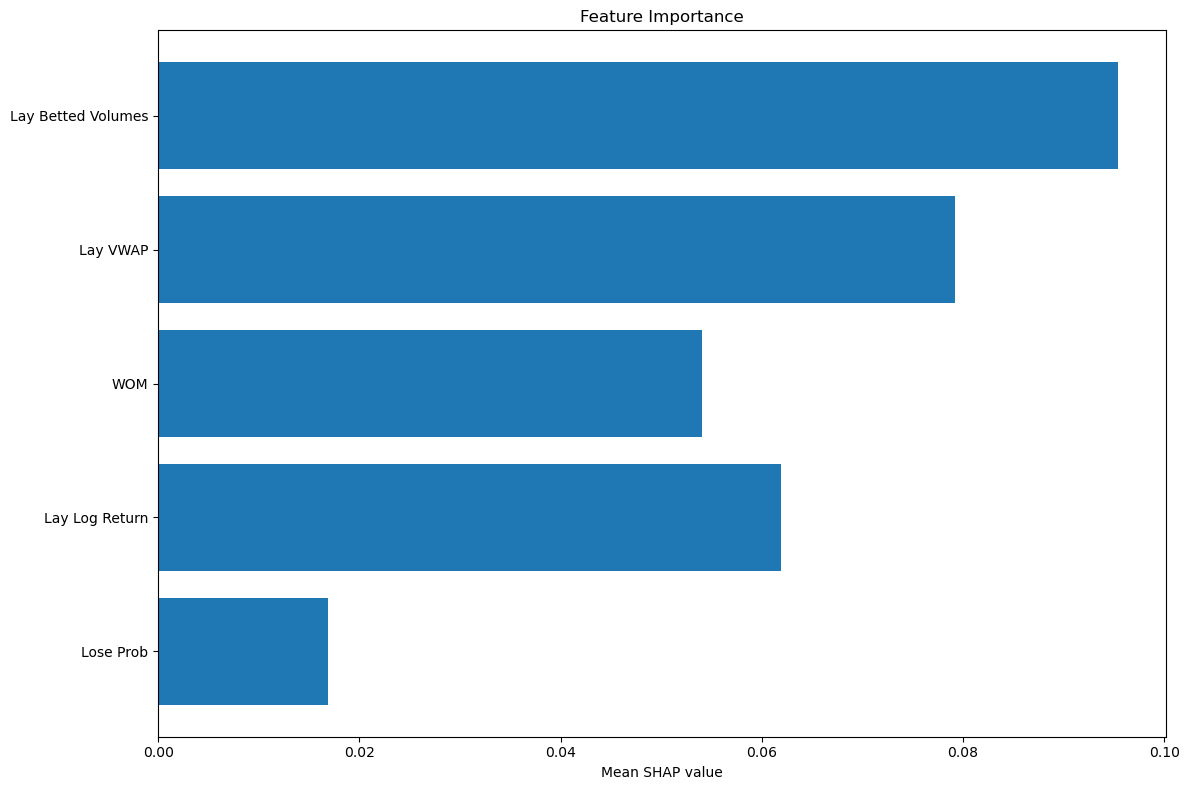

'\\begin{table}[h!]\n\\begin{tabular}{lr}\n\\toprule\nfeature_names & feature_importance (%) \\\\\n\\midrule\nLay Betted Volumes & 31.1 \\\\\nLay VWAP & 25.8 \\\\\nWOM & 17.6 \\\\\nLay Log Return & 20.1 \\\\\nLose Prob & 5.5 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [15]:
feature_importance_table(lose_XGBoost_results['model'], lose_XGBoost_results['X_test'], ['Lay Betted Volumes',
                                                                                            'Lay VWAP',
                                                                                            'WOM',
                                                                                            'Lay Log Return',
                                                                                            'Lose Prob'] )